In [2]:
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

In [3]:
methods = ["F_SV", "F_refined_SV"]
methods_l = ["Fourier with SV", "Fourier refined with SV"]

all_markers = ["o"]
colors = [ "#e41a1c", "cyan"]
opts = {"mec": "k", "ecolor": "k", "capsize": 3, "elinewidth": 1}

In [4]:
def collect_sv_energy_by_depth(files_glob, data_dir):
    """Return dict method -> {depth -> list of energies}. Skips files that fail to load."""
    method_to_files = {t: [] for t in methods}
    for fp in sorted(data_dir.glob(files_glob)):
        low = fp.name.lower()
        for t in methods:
            if t.lower() in low:
                print(t)
                method_to_files[t].append(fp)
                break
    parsed = {}
    for fp in sum(method_to_files.values(), []):
        if fp in parsed:
            continue
        try:
            parsed[fp] = json.loads(fp.read_text())
        except Exception as e:
            print(f"[WARN] Skipping {fp.name}: {e}")
            continue
    points_D_method = {t: {} for t in methods}
    for m, fps in method_to_files.items():
        for fp in fps:
            data = parsed.get(fp)
            if not data:
                continue
            try:
                N = re.search(r"N(\d+)", fp.name).group(1)
                fam_param = re.search(
                    r"N\d+(ER\d+|HH\d+|L\d+S\d+|R\d+R)", Path(fp.name).stem, re.IGNORECASE
                ).group(1)
            except (AttributeError, IndexError):
                continue
            if int(N) != size_allowed or fam_param != fam_param_allowed:
                continue
            try:
                depth = re.search(r"_(\d+)$", Path(fp.name).stem).group(1)
            except (AttributeError, IndexError):
                continue
            E = data.get(list(data.keys())[-1], {}).get("energy")
            if E is None or E == "NA":
                continue
            try:
                points_D_method[m].setdefault(int(depth), []).append(float(E))
            except (TypeError, ValueError):
                continue
    return points_D_method


F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV
F_SV


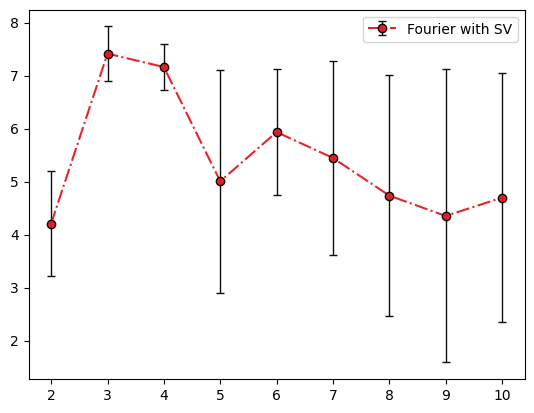

In [5]:
data_dir_2 = Path("../data/training/random_regular")
size_allowed = 20
fam_param_allowed = "R3R"

points_MC = collect_sv_energy_by_depth("*N20R3R*MC*.json", data_dir_2)

plt.figure()
for i, m in enumerate(methods):
    D_to_vals = points_MC.get(m, {})
    if not D_to_vals:
        continue
    xs = sorted(D_to_vals.keys())
    means = [float(np.mean(D_to_vals[k])) for k in xs]
    stds = [float(np.std(D_to_vals[k], ddof=0)) for k in xs]
    xs_arr = np.array(xs, dtype=float)
    opts_sv = {**opts, "marker": all_markers[0]}
    plt.errorbar(xs_arr, means, yerr=stds, alpha=0.95, label=methods_l[i], color=colors[i], linestyle="-.", **opts_sv)


plt.legend()

plt.show()